In [1]:
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable


[stable] Iter 0: Loss 4.4109, Sensitivity 0.2958
[stable] Iter 100: Loss 2.6667, Sensitivity 0.3060
[stable] Iter 200: Loss 2.3319, Sensitivity 0.4114
[stable] Iter 300: Loss 0.3998, Sensitivity 0.6426
[stable] Iter 400: Loss 0.1617, Sensitivity 0.7255
[stable] Iter 500: Loss 0.0951, Sensitivity 0.7529
[stable] Iter 600: Loss 0.0707, Sensitivity 0.7737
[stable] Iter 700: Loss 0.0612, Sensitivity 0.7799
[stable] Iter 800: Loss 0.0541, Sensitivity 0.7814
[stable] Iter 900: Loss 0.0456, Sensitivity 0.7998
[stable] Iter 1000: Loss 0.0476, Sensitivity 0.7913
[stable] Iter 1100: Loss 0.0574, Sensitivity 0.8122
[stable] Iter 1200: Loss 0.0466, Sensitivity 0.8072
[stable] Iter 1300: Loss 0.0495, Sensitivity 0.8396
[stable] Iter 1400: Loss 0.0486, Sensitivity 0.8280
[stable] Iter 1500: Loss 0.0392, Sensitivity 0.8297
[stable] Iter 1600: Loss 0.0418, Sensitivity 0.8439
[stable] Iter 1700: Loss 0.0452, Sensitivity 0.8646
[stable] Iter 1800: Loss 0.0444, Sensitivity 0.8513
[stable] Iter 1900: Loss

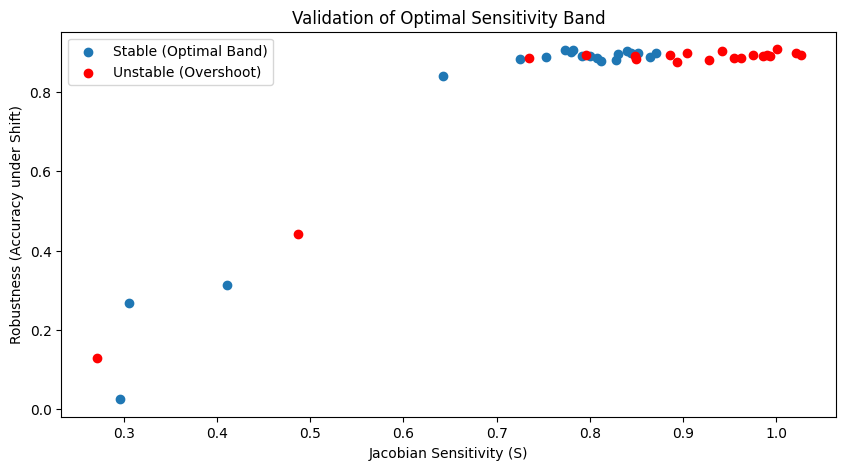

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Hyperparameters ---
batch_size = 32
block_size = 64
max_iters = 2000 
eval_interval = 100
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1
eta = 1e-3

# --- 2. Data Preparation ---
# Load a small text file for character-level training
import urllib.request
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9*len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# --- 3. Transformer Building Blocks ---
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = nn.MultiheadAttention(n_embd, n_head, dropout=dropout, batch_first=True)
        self.ffwd = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        attn_output, _ = self.sa(self.ln1(x), self.ln1(x), self.ln1(x))
        x = x + attn_output
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, device=device)
        x = self.wte(idx) + self.wpe(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1)) if targets is not None else None
        return logits, loss

    def forward_from_embeddings(self, x):
        x = self.blocks(x)
        x = self.ln_f(x)
        return self.lm_head(x)

# --- 4. Research Metrics ---
def get_sensitivity(model, x):
    model.eval()
    with torch.no_grad():
        emb = model.wte(x) + model.wpe(torch.arange(block_size, device=device))
        v = torch.randn_like(emb)
        v = v / torch.norm(v, p=2)
        l_orig = model.forward_from_embeddings(emb)
        l_pert = model.forward_from_embeddings(emb + eta * v)
        s = torch.norm(l_pert - l_orig, p='fro') / eta
    model.train()
    return s.item()

def get_val_robustness(model):
    # Measures accuracy on validation data with added character noise
    model.eval()
    with torch.no_grad():
        x, y = get_batch('val')
        # Simulate distribution shift: random token replacement
        noise_mask = torch.rand(x.shape, device=device) < 0.1
        x_noisy = x.clone()
        x_noisy[noise_mask] = torch.randint(0, vocab_size, (noise_mask.sum(),), device=device)
        
        logits, _ = model(x_noisy)
        acc = (logits.argmax(-1) == y).float().mean()
    model.train()
    return acc.item()

# --- 5. Training Loop with History Initialization ---
def run_experiment(mode='stable'):
    model = GPT().to(device)
    lr = 3e-4 if mode == 'stable' else 1e-3
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    # INITIALIZE HISTORY HERE
    history = {'loss': [], 'sensitivity': [], 'robustness': []}
    
    for i in range(max_iters):
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if i % eval_interval == 0:
            s = get_sensitivity(model, xb)
            r = get_val_robustness(model)
            history['loss'].append(loss.item())
            history['sensitivity'].append(s)
            history['robustness'].append(r)
            print(f"[{mode}] Iter {i}: Loss {loss.item():.4f}, Sensitivity {s:.4f}")
            
    return history

# --- 6. Execution and Plotting ---
stable_hist = run_experiment('stable')
unstable_hist = run_experiment('unstable')

plt.figure(figsize=(10, 5))
plt.scatter(stable_hist['sensitivity'], stable_hist['robustness'], label='Stable (Optimal Band)')
plt.scatter(unstable_hist['sensitivity'], unstable_hist['robustness'], label='Unstable (Overshoot)', color='red')
plt.xlabel('Jacobian Sensitivity (S)')
plt.ylabel('Robustness (Accuracy under Shift)')
plt.legend()
plt.title('Validation of Optimal Sensitivity Band')
plt.show()

In [5]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def plot_quadratic_fit(sensitivity_data, robustness_data):
    """
    Fits a 2nd-degree polynomial to prove the 'Optimal Band' theory.
    """
    # Convert lists to numpy arrays and reshape for sklearn
    S = np.array(sensitivity_data).reshape(-1, 1)
    R = np.array(robustness_data).reshape(-1, 1)
    
    # 1. Create quadratic features: [1, S, S^2]
    poly = PolynomialFeatures(degree=2)
    S_poly = poly.fit_transform(S)
    
    # 2. Fit the linear regression
    model = LinearRegression()
    model.fit(S_poly, R)
    
    # 3. Generate points for the smooth curve plot
    S_range = np.linspace(S.min(), S.max(), 100).reshape(-1, 1)
    S_range_poly = poly.transform(S_range)
    R_pred = model.predict(S_range_poly)
    
    # 4. Calculate the Peak (Optimal Sensitivity S*)
    # For y = ax^2 + bx + c, the peak is at x = -b / 2a
    coef = model.coef_.flatten() # [intercept, b, a]
    b = coef[1]
    a = coef[2]
    s_star = -b / (2 * a)


    from sklearn.metrics import r2_score
    # 5. Predict robustness using the fitted model
    R_pred_all = model.predict(S_poly)
    
    # 6. Calculate R^2
    # # This compares the actual R values to the predicted values on the curve
    
    r2 = r2_score(R, R_pred_all)
    
    print(f"--- Statistical Goodness of Fit ---")
    print(f"R-squared (R²): {r2:.4f}")
    print("-----------------------------------")
    
    # --- Plotting ---
    plt.figure(figsize=(8, 5),dpi=500)
    plt.scatter(S, R, color='black', alpha=0.5, label='Actual Checkpoints')
    plt.plot(S_range, R_pred, color='red', linewidth=2, label=f'Quadratic Fit (Peak S* ≈ {s_star:.3f})')
    
    plt.axvline(x=s_star, color='gray', linestyle='--', label='Optimal Sensitivity')
    plt.xlabel('Jacobian Sensitivity (S)')
    plt.ylabel('Robustness (OOD Accuracy)')
    plt.title('Sensitivity–Robustness Relationship in a Transformer Language Model')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("GPT_sensitivity_quadratic.pdf", bbox_inches="tight")
    plt.show()
    
    return s_star


--- Statistical Goodness of Fit ---
R-squared (R²): 0.9688
-----------------------------------


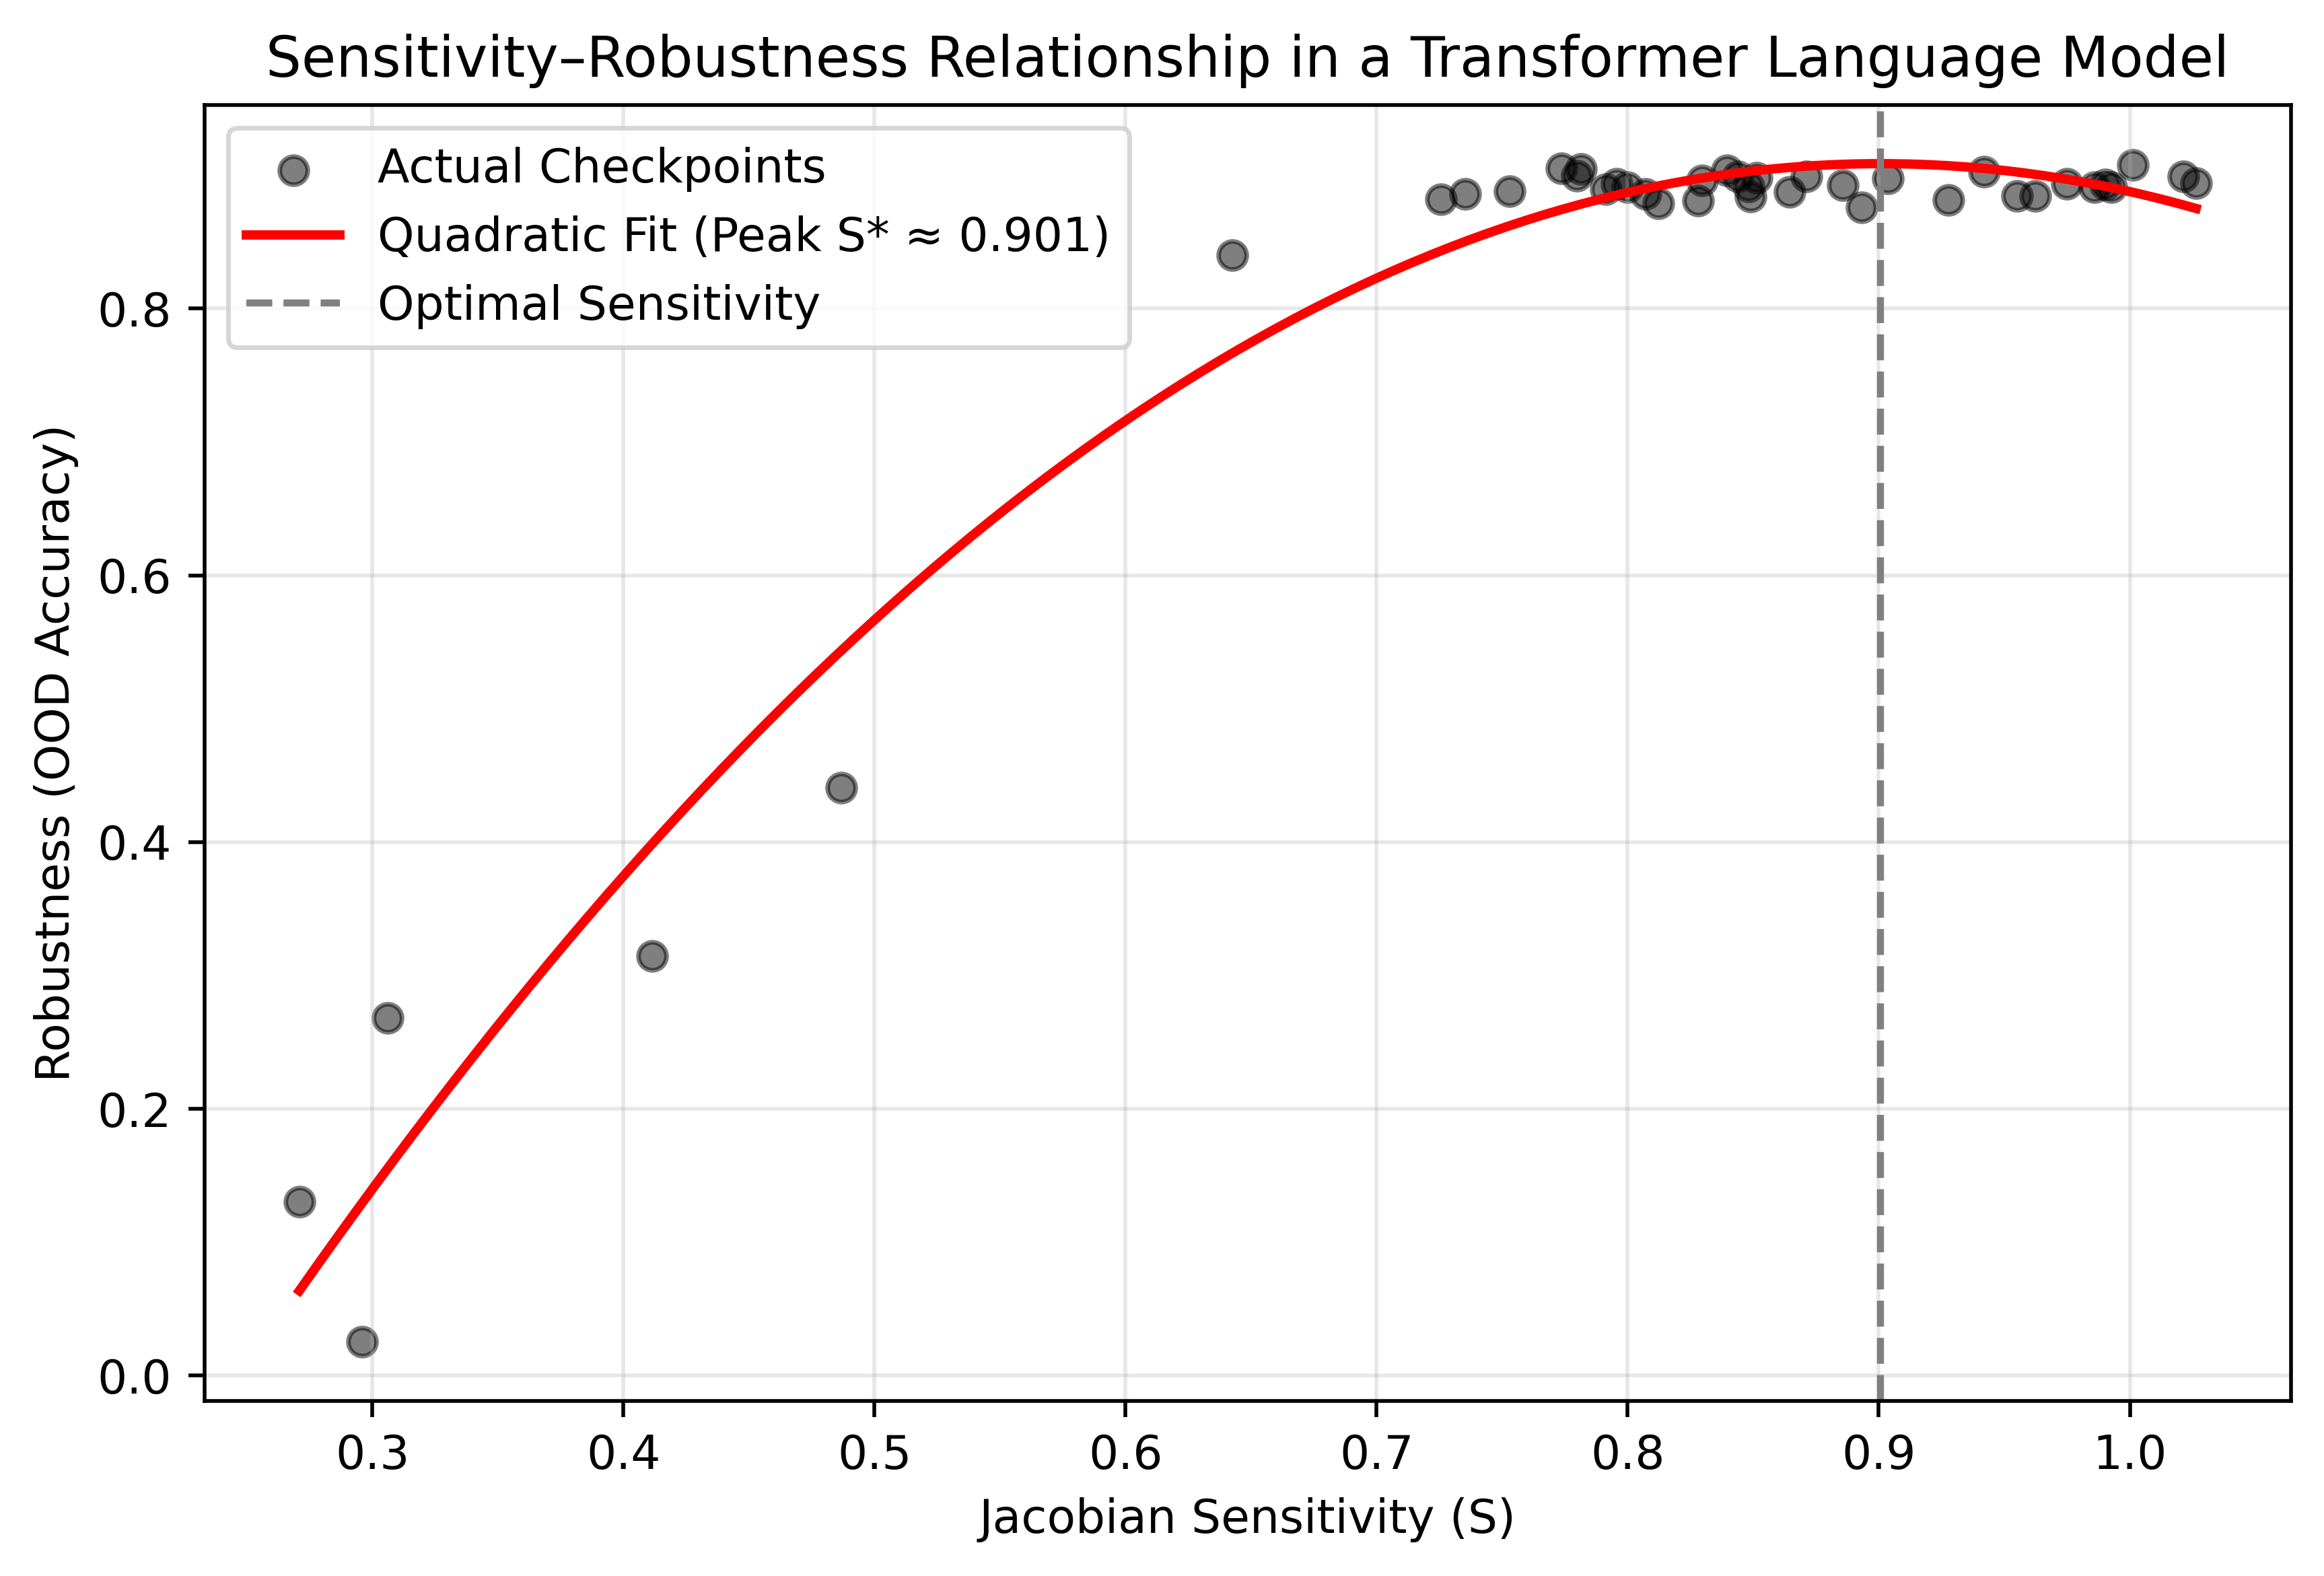

The Optimal Sensitivity for this GPT model is: 0.9008


In [6]:
# 1. Combine the data from both training runs
all_sensitivity = stable_hist['sensitivity'] + unstable_hist['sensitivity']
all_robustness = stable_hist['robustness'] + unstable_hist['robustness']

# 2. Call the Quadratic Fit function (make sure the function is defined in your script!)
s_star = plot_quadratic_fit(all_sensitivity, all_robustness)

print(f"The Optimal Sensitivity for this GPT model is: {s_star:.4f}")

a = -2.130149, b = 3.837558, c = -0.819652
S* = 0.900772
R(S*) = 0.908731
1% band: (0.8354573541141957, 0.9660873136207913)
2% band: (0.8084030036742558, 0.9931416640607312)
5% band: (0.754723599190098, 1.0468210685448889)


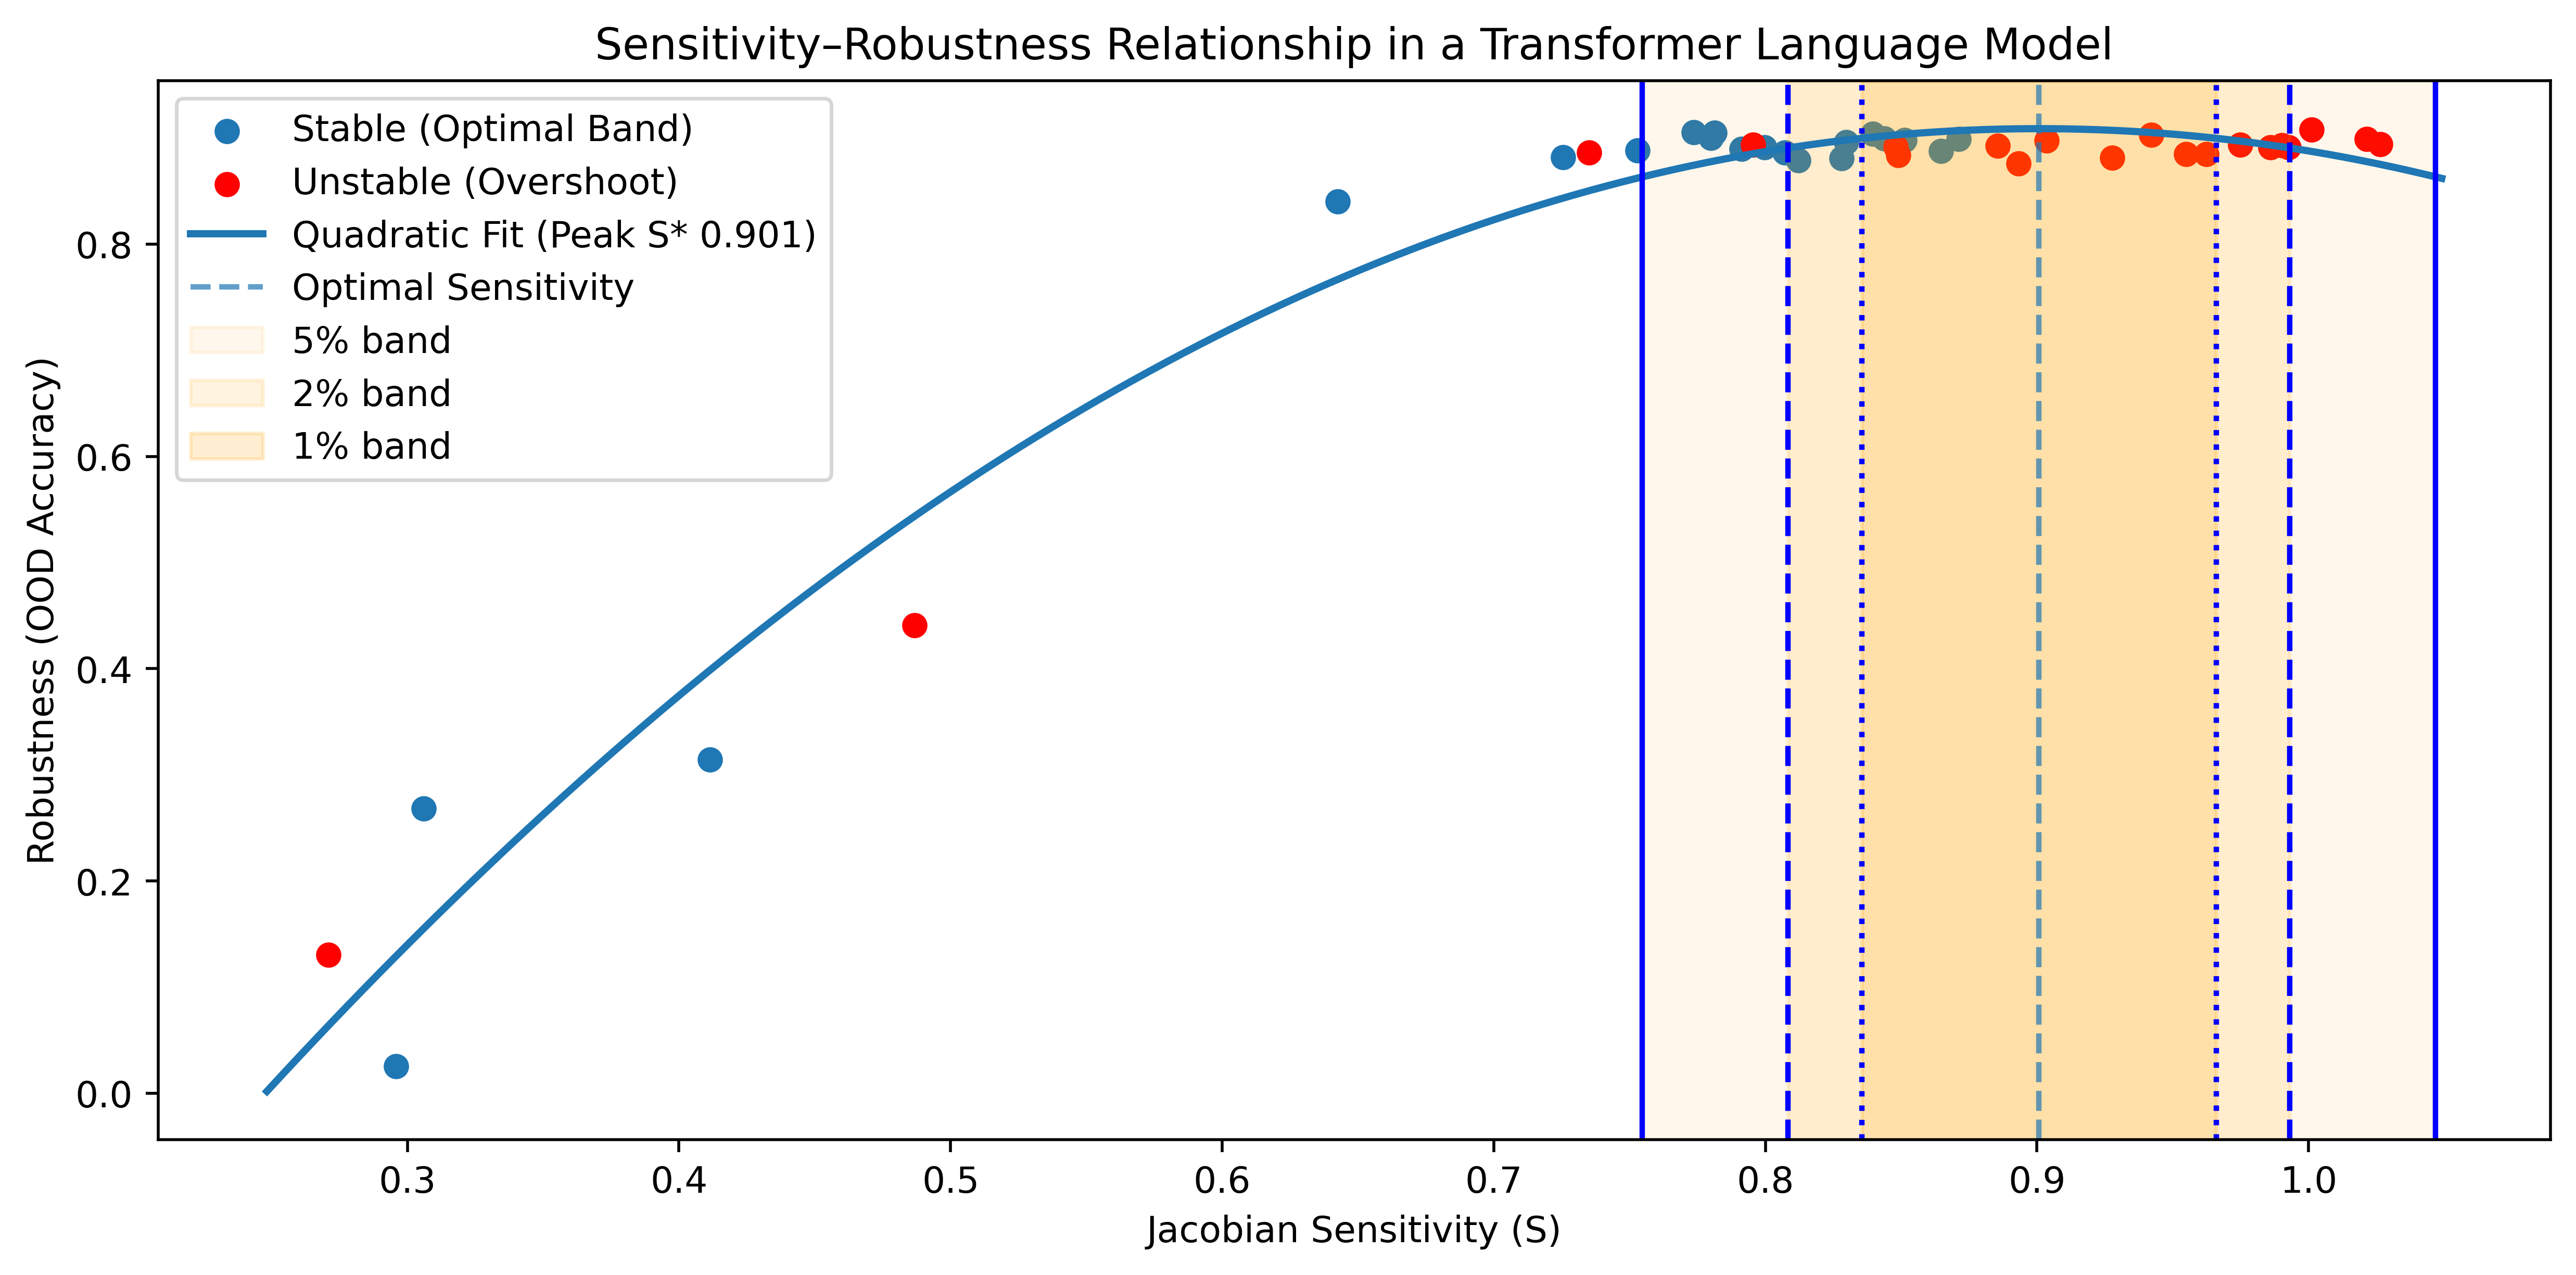

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Gather all checkpoints
# --------------------------------------------------
S_all = np.array(stable_hist['sensitivity'] + unstable_hist['sensitivity'], dtype=float)
R_all = np.array(stable_hist['robustness'] + unstable_hist['robustness'], dtype=float)

S_stable = np.array(stable_hist['sensitivity'], dtype=float)
R_stable = np.array(stable_hist['robustness'], dtype=float)

S_unstable = np.array(unstable_hist['sensitivity'], dtype=float)
R_unstable = np.array(unstable_hist['robustness'], dtype=float)

# --------------------------------------------------
# 2. Fit quadratic: R(S) = a S^2 + b S + c
# --------------------------------------------------
a, b, c = np.polyfit(S_all, R_all, 2)

if a >= 0:
    print("Warning: fitted quadratic is not concave. Band interpretation may be unreliable.")

# Optimal sensitivity
S_star = -b / (2 * a)
R_star = a * S_star**2 + b * S_star + c

print(f"a = {a:.6f}, b = {b:.6f}, c = {c:.6f}")
print(f"S* = {S_star:.6f}")
print(f"R(S*) = {R_star:.6f}")

# --------------------------------------------------
# 3. Function to compute eta-optimal band
#    Band = {S : R(S) >= (1 - eta) R(S*)}
# --------------------------------------------------
def compute_eta_band(a, b, c, eta):
    target = (1.0 - eta) * R_star

    # Solve a S^2 + b S + c = target
    A = a
    B = b
    C = c - target

    disc = B**2 - 4 * A * C
    if disc < 0:
        return None

    sqrt_disc = np.sqrt(disc)
    s1 = (-B - sqrt_disc) / (2 * A)
    s2 = (-B + sqrt_disc) / (2 * A)

    left = min(s1, s2)
    right = max(s1, s2)
    return left, right

band_1 = compute_eta_band(a, b, c, eta=0.01)
band_2 = compute_eta_band(a, b, c, eta=0.02)
band_5 = compute_eta_band(a, b, c, eta=0.05)

print("1% band:", band_1)
print("2% band:", band_2)
print("5% band:", band_5)

# --------------------------------------------------
# 4. Plot with 1%, 2%, 5% bands
# --------------------------------------------------
xmin = min(S_all.min(), S_star) - 0.03 * (S_all.max() - S_all.min())
xmax = max(S_all.max(), S_star) + 0.03 * (S_all.max() - S_all.min())
xgrid = np.linspace(xmin, xmax, 400)
ygrid = a * xgrid**2 + b * xgrid + c

plt.figure(figsize=(10, 5),dpi=500)

# Scatter
plt.scatter(S_stable, R_stable, label='Stable (Optimal Band)')
plt.scatter(S_unstable, R_unstable, label='Unstable (Overshoot)', color='red')

# Quadratic fit
plt.plot(xgrid, ygrid, linewidth=2, label=f'Quadratic Fit (Peak S* {S_star:.3f})')

# Peak line
plt.axvline(S_star, linestyle='--', linewidth=1.5, alpha=0.7, label='Optimal Sensitivity')


# Bands
if band_5 is not None:
    plt.axvspan(band_5[0], band_5[1], alpha=0.08, label='5% band',color='orange')
    plt.axvline(band_5[0], linestyle="-",color='blue'); plt.axvline(band_5[1], linestyle="-",color='blue')
if band_2 is not None:
    plt.axvspan(band_2[0], band_2[1], alpha=0.12, label='2% band',color='orange')
    plt.axvline(band_2[0], linestyle="--",color='blue'); plt.axvline(band_2[1], linestyle="--",color='blue')
if band_1 is not None:
    plt.axvspan(band_1[0], band_1[1], alpha=0.18, label='1% band',color='orange')
    plt.axvline(band_1[0], linestyle=":",color='blue'); plt.axvline(band_1[1], linestyle=":",color='blue')

plt.xlabel('Jacobian Sensitivity (S)')
plt.ylabel('Robustness (OOD Accuracy)')
plt.title('Sensitivity–Robustness Relationship in a Transformer Language Model')
plt.legend()
plt.tight_layout()
plt.savefig("GPT_band_sensitivity_quadratic.pdf", bbox_inches="tight")
plt.show()